In [84]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno

In [85]:
# Set max columns
pd.set_option('display.max_columns', None)

## **0. Data Understanding**

**Data Overview**

- File: `hotel_bookings.csv`

- Records: 119390 data pemesanan

- Columns: 32 columns

- Target variable: `is_canceled` (pemesanan dibatalkan (1) atau tidak dibatalkan (0))

- Cancellation rate: ~15% (7,478 out of 50,000 bookings)

**Column Descriptions**

**1. Variabel Target (Outcome)**
- `is_canceled`
Nilai yang menunjukkan apakah pemesanan dibatalkan (1) atau tidak (0)

**2. Waktu pemesanan & menginap**
- `lead_time`
Jumlah hari yang berlalu antara tanggal memasukkan pemesanan ke dalam PMS dan tanggal kedatangan
- `arrival_date_year`
Year of arrival date
- `arrival_date_month`
month of arrival date
- `arrival_date_week_number`
Week number of year for arrival date
- `arrival_date_day_of_month`
Day of arrival date
- `stays_in_weekend_nights`
Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel
- `stays_in_week_nights`
Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel

**3. profil tamu & pemesanan**
- `hotel`
Hotel (H1 = Resort Hotel or H2 = City Hotel)
- `adults`
Number of adults
- `children`
Number of children
- `babies`
Number of babies
- `country`
Country of origin. Categories are represented in the ISO 3155–3:2013 format
- `market_segment`
Penamaan segmen pasar. Dalam kategori, istilah 
    - “TA” berarti “Agen Perjalanan”
    - “TO” berarti “Operator Tur”
- `distribution_channel`
Saluran distribusi pemesanan. Istilah 
    - “TA” berarti “Agen Perjalanan”
    - “TO” berarti “Operator Tur”
    - "Direct" berarti langsung
- `agent`
ID of the travel agency that made the booking
- `company`
Identitas perusahaan/entitas yang melakukan pemesanan atau bertanggung jawab atas pembayaran pemesanan. Identitas ditampilkan sebagai pengganti jabatan untuk alasan anonimitas.

**4. Detail kamar & layanan**
- `meal`
Jenis makanan yang dipesan. Kategori disajikan dalam paket makan standar perhotelan: 
    -Tidak ditentukan/SC – tanpa paket makan; 
    - BB – Sarapan dan Penginapan; 
    - HB – Setengah papan (sarapan dan satu makanan lainnya – biasanya makan malam); 
    - FB – Papan penuh (sarapan, makan siang, dan makan malam)
- `reserved_room_type`
Kode tipe kamar yang dipesan. Kode ditampilkan sebagai pengganti nama kamar untuk alasan anonimitas.
- `assigned_room_type`
Kode untuk tipe kamar yang ditetapkan untuk pemesanan. Terkadang tipe kamar yang ditetapkan berbeda dari tipe kamar yang dipesan karena alasan operasional hotel (misalnya kelebihan pemesanan) atau atas permintaan pelanggan. Kode ditampilkan sebagai pengganti penunjukan untuk alasan anonimitas
- `customer_type`
Jenis pemesanan, dengan asumsi salah satu dari empat kategori: 
    -  Contract - ketika pemesanan memiliki alokasi atau jenis kontrak lain yang terkait dengannya
    - Grup – ketika pemesanan terkait dengan sebuah grup
    - Transient – ketika pemesanan bukan bagian dari grup atau kontrak, dan tidak terkait dengan pemesanan tamu tunggal lainnya
    - Transient-party – ketika pemesanan bersifat tamu tunggal, tetapi terkait dengan setidaknya satu pemesanan tamu tunggal lainnya

**5. Risiko & keuangan**
- `is_repeated_guest`
Nilai yang menunjukkan apakah nama pemesanan berasal dari tamu berulang (1) atau bukan (0)
- `previous_cancellations`
Jumlah pemesanan sebelumnya yang dibatalkan oleh pelanggan sebelum pemesanan saat ini.
- `previous_bookings_not_canceled`
Jumlah pemesanan sebelumnya yang tidak dibatalkan oleh pelanggan sebelum pemesanan saat ini
- `deposit_type`
Indikasi apakah pelanggan melakukan pembayaran uang muka untuk menjamin pemesanan. Variabel ini dapat dikategorikan menjadi tiga kelompok: 
    - No Deposit – tidak ada uang muka yang dibayarkan
    - Non Refund – uang muka dibayarkan senilai total biaya menginap
    - Refundable – uang muka dibayarkan dengan nilai di bawah total biaya menginap
- `adr`
Tarif Harian Rata-Rata, didefinisikan sebagai membagi jumlah total transaksi penginapan dengan total jumlah malam menginap
- `required_car_parking_spaces`
Number of car parking spaces required by the customer
- `total_of_special_requests`
Jumlah permintaan khusus yang diajukan oleh pelanggan (misalnya tempat tidur kembar atau lantai atas)
- `reservation_status`
Status reservasi terakhir, dengan asumsi salah satu dari tiga kategori berikut: 
    - Canceled – pemesanan dibatalkan oleh pelanggan
    - Check-Out – pelanggan telah check-in tetapi sudah check-out
    - No-Show – pelanggan tidak check-in dan tidak memberi tahu hotel alasannya.
- `reservation_status_date`
Tanggal saat status terakhir ditetapkan. Variabel ini dapat digunakan bersama dengan ReservationStatus untuk memahami kapan pemesanan dibatalkan atau kapan pelanggan melakukan check-out dari hotel.
- `booking_changes`
Jumlah perubahan/amandemen yang dilakukan pada pemesanan sejak pemesanan dimasukkan ke dalam PMS hingga saat check-in atau pembatalan
- `days_in_waiting_list`
Jumlah hari pemesanan berada dalam daftar tunggu sebelum dikonfirmasi kepada pelanggan.

## **1. Data Loading**

In [86]:
# Load dataset
df = pd.read_csv("C:/Users/HP/Documents/FINPRO DS/hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

## **2. Data Cleaning**

- **Matrix plot**

<Axes: >

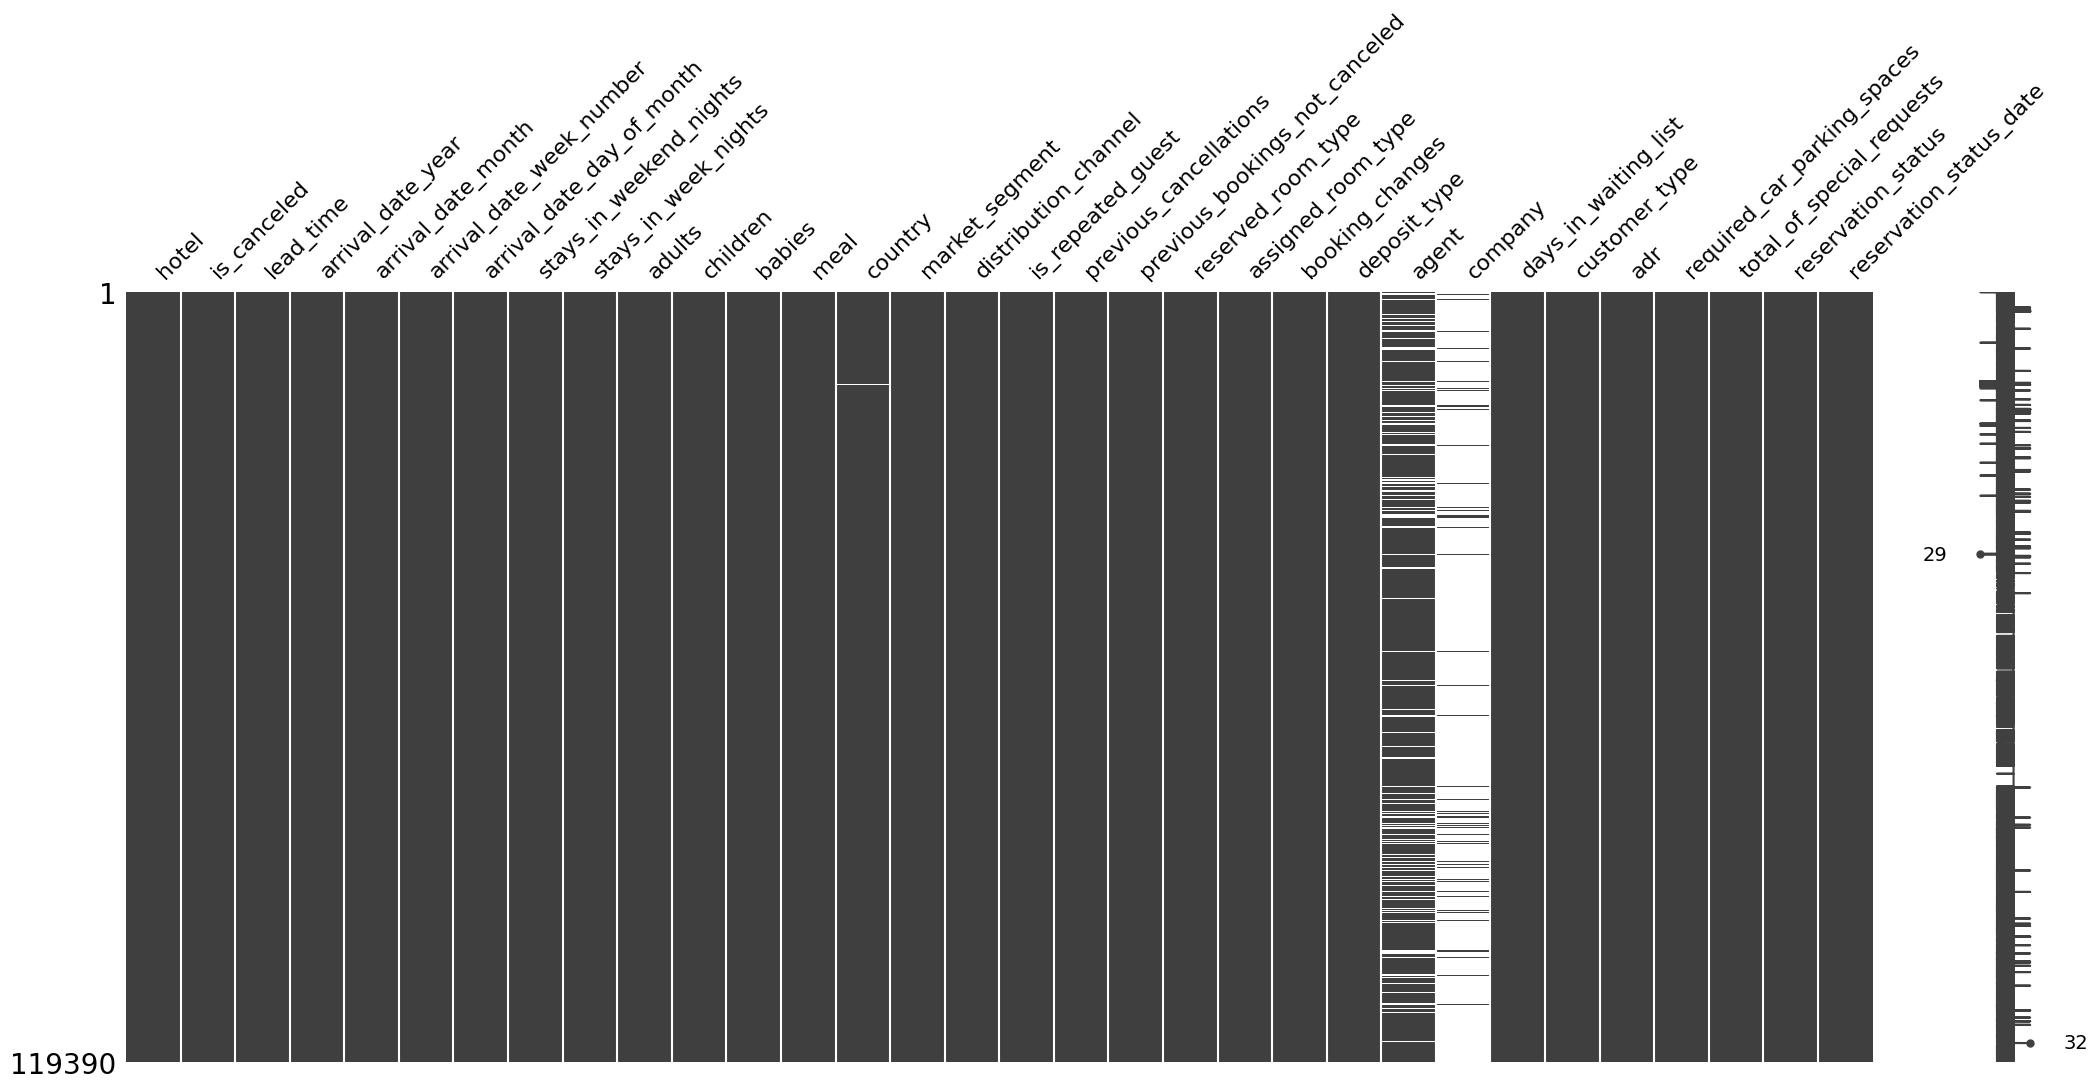

In [88]:
missingno.matrix(df)

Terlihat bahwa missing value/data yang hilang pada setiap kolom memiliki pola yang cukup acak.

- **Heatmap**

Korelasi nulitas berkisar dari -1 hingga 1.

jika bernilai -1 --> Korelasi Negatif yang menyatakan bahwa jika nilai satu variabel ada maka nilai variabel lain pasti tidak ada.

jika bernilai 0 --> Tidak ada korelasi yang menyatakan bahwa nilai variabel yang ada atau tidak ada tidak berpengaruh satu sama lain.

jika bernilai 1 --> Korelasi Positif yang menyatakan bahwa jika nilai satu variabel ada maka nilai yang lain pasti ada

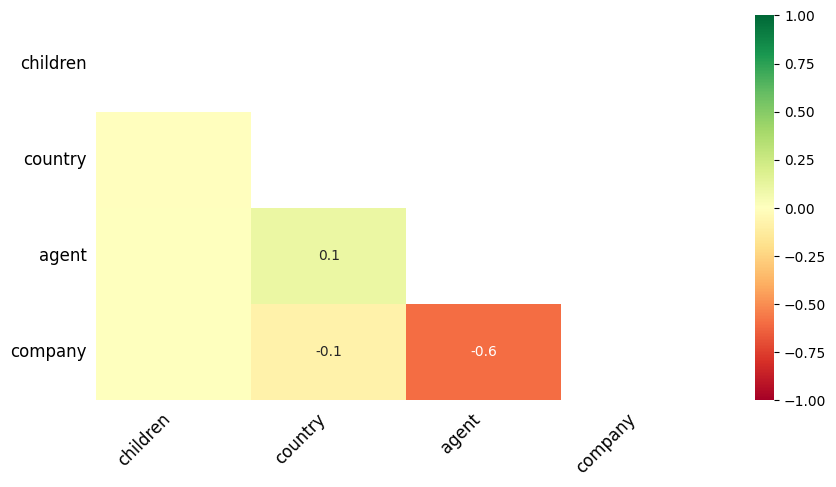

In [89]:
missingno.heatmap(df, cmap="RdYlGn", figsize=(10,5), fontsize=12);

**Insight:**

Terlihat dari Heatmap tersebut, bahwa rata-rata data yang hilang satu kolom dengan kolom yang lainnya itu tidak berhubungan/berkorelasi, tetapi untuk kolom company dengan kolom agent memiliki hubungan/korelasi yang cukup kuat dengan nilai -0.6 yang berartikan bahwa bila kolom company itu ada datanya, biasanya kolom agent tidak ada datanya dan begitu pula sebaliknya.

- **Dendogram**

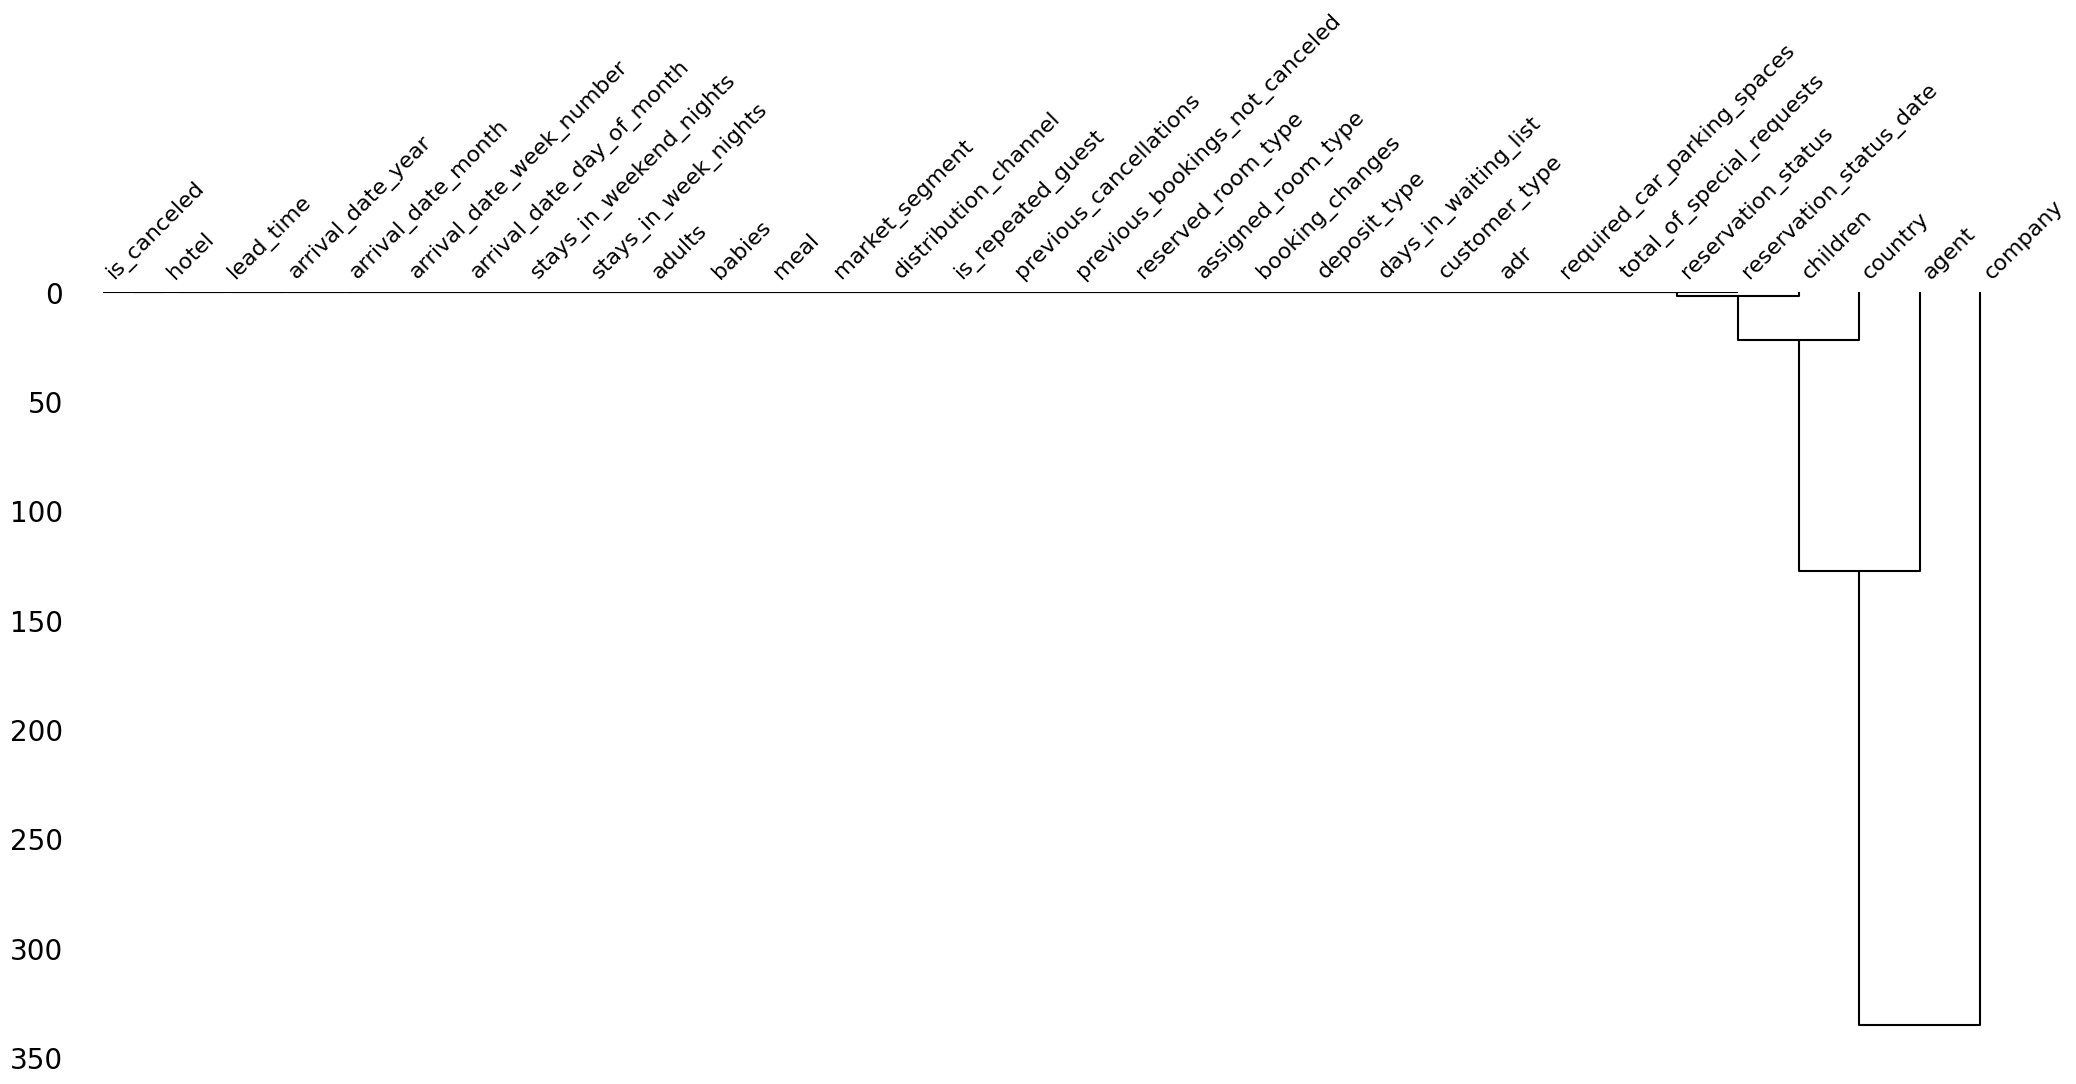

In [90]:
missingno.dendrogram(df)
plt.show()

In [91]:
data_kosong = df.isna().sum()
data_kosong[data_kosong>0]

children         4
country        488
agent        16340
company     112593
dtype: int64

**Insight:**

Terdapat 4 kolom yang memiliki missing value yaitu kolom children, country, agent, dan company.

In [92]:
listItem = []
for col in df.columns :
    listItem.append([col, df[col].dtype, df[col].isna().sum(), round((df[col].isna().sum()/len(df[col])) * 100,2),
                    df[col].nunique(), list(df[col].drop_duplicates().sample(2).values)]);

dfDesc = pd.DataFrame(columns=['dataFeatures', 'dataType', 'null', 'nullPct', 'unique', 'uniqueSample'],
                     data=listItem)
dfDesc

,dataFeatures,dataType,null,nullPct,unique,uniqueSample
0,hotel,object,0,0.00,2,"[City Hotel, Resort Hotel]"
1,is_canceled,int64,0,0.00,2,"[0, 1]"
2,lead_time,int64,0,0.00,479,"[125, 424]"
3,arrival_date_year,int64,0,0.00,3,"[2015, 2017]"
4,arrival_date_month,object,0,0.00,12,"[April, May]"
5,arrival_date_week_number,int64,0,0.00,53,"[15, 6]"
6,arrival_date_day_of_month,int64,0,0.00,31,"[21, 4]"
7,stays_in_weekend_nights,int64,0,0.00,17,"[19, 5]"
8,stays_in_week_nights,int64,0,0.00,35,"[18, 35]"
9,adults,int64,0,0.00,14,"[20, 10]"


**Insight:**

- Nilai NaN pada kolom children dan country relatif sedikit yaitu dibawa 1% dari keseluruhan data sehingga bisa dihapus langsung.

- Kolom agent dan company ialah ID dari agent dan company untuk tiap pemesanan (booking) hotel, nilai NaN tersebut mengidentifikasikan pemesanan hotel tidak melalui agent dan pemesanan perusahaan biasanya secara langsung oleh karena itu akan diisi dengan 0 sebagai "no agent"

- Sesuai dengan kesimpulan Heatmap sebelumnya bila kolom company itu ada datanya, biasanya kolom agent tidak ada datanya dan begitu pula sebaliknya. sehingga kita asumsikan bahwa nilai NaN di company berarti pemesanan langsung.


In [93]:
hapus_kolom = ["children","country"]
df.dropna(subset= hapus_kolom, inplace= True)

In [94]:
# Menggunakan query
df.query('agent.isna()')[['agent','distribution_channel']]

,agent,distribution_channel
0,NaN,Direct
1,NaN,Direct
2,NaN,Direct
6,NaN,Direct
18,NaN,Corporate
...,...,...
119124,NaN,Corporate
119151,NaN,Direct
119166,NaN,Direct
119215,NaN,Direct


In [95]:
df.loc[df["agent"].isnull(), "agent"]= 0

In [96]:
df.loc[df['company'].isna(), ['company','distribution_channel', 'agent']]

,company,distribution_channel,agent
0,NaN,Direct,0.0
1,NaN,Direct,0.0
2,NaN,Direct,0.0
3,NaN,Corporate,304.0
4,NaN,TA/TO,240.0
...,...,...,...
119385,NaN,TA/TO,394.0
119386,NaN,TA/TO,9.0
119387,NaN,TA/TO,9.0
119388,NaN,TA/TO,89.0


In [97]:
df.loc[df['company'].notna(), ['company','distribution_channel', 'agent']]

,company,distribution_channel,agent
18,110.0,Corporate,0.0
218,110.0,Corporate,0.0
219,110.0,Corporate,0.0
220,110.0,Corporate,0.0
295,113.0,Corporate,0.0
...,...,...,...
119119,451.0,Corporate,0.0
119122,451.0,Corporate,0.0
119123,451.0,Corporate,0.0
119124,72.0,Corporate,0.0


In [98]:
df.loc[df["company"].isnull(), "company"]= 0

In [99]:
df.isna().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

**Cek duplicated**

In [103]:
df.duplicated().sum()

np.int64(31958)

In [109]:
df[df.duplicated()].head(20)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0.0,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,1,No Deposit,250.0,0.0,0,Transient,84.67,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,0.0,0,HB,ROU,Direct,Direct,0,0,0,E,E,0,No Deposit,250.0,0.0,0,Transient,137.00,0,1,Check-Out,2015-07-07
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,240.0,0.0,0,Transient,97.00,0,0,Canceled,2015-07-01
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0.0,0,Transient,109.80,0,3,Check-Out,2015-07-08
219,Resort Hotel,1,1,2015,July,28,8,0,1,2,0.0,0,BB,PRT,Corporate,Corporate,0,0,0,A,A,0,No Deposit,0.0,110.0,0,Transient,104.72,0,1,Canceled,2015-07-08
256,Resort Hotel,0,91,2015,July,28,10,0,2,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0.0,0,Transient,73.80,0,1,Check-Out,2015-07-12
261,Resort Hotel,0,30,2015,July,28,10,2,2,2,0.0,0,FB,PRT,Direct,Direct,0,0,0,F,F,0,No Deposit,0.0,0.0,0,Transient-Party,197.00,0,1,Check-Out,2015-07-14
353,Resort Hotel,0,98,2015,July,29,13,1,1,2,0.0,0,BB,ESP,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0.0,0,Transient-Party,82.00,0,3,Check-Out,2015-07-15
372,Resort Hotel,0,40,2015,July,29,13,1,4,2,0.0,0,BB,ESP,Direct,Direct,0,0,0,D,D,0,No Deposit,250.0,0.0,0,Transient,120.00,0,2,Check-Out,2015-07-18


In [110]:
df.drop_duplicates(inplace=True)

In [111]:
df.duplicated().sum()

np.int64(0)

In [112]:
df.head(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [113]:
df_ml = df.copy()
df_analysis = df.copy()

In [114]:
df.to_csv("data_bersih_hotel.csv")
print("data berhasil")

data berhasil


In [105]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,118898.0,0.371352,0.483168,0.00,0.0,0.0,1.0,1.0
lead_time,118898.0,104.311435,106.903309,0.00,18.0,69.0,161.0,737.0
arrival_date_year,118898.0,2016.157656,0.707459,2015.00,2016.0,2016.0,2017.0,2017.0
arrival_date_week_number,118898.0,27.166555,13.589971,1.00,16.0,28.0,38.0,53.0
arrival_date_day_of_month,118898.0,15.800880,8.780324,1.00,8.0,16.0,23.0,31.0
stays_in_weekend_nights,118898.0,0.928897,0.996216,0.00,0.0,1.0,2.0,16.0
stays_in_week_nights,118898.0,2.502145,1.900168,0.00,1.0,2.0,3.0,41.0
adults,118898.0,1.858391,0.578576,0.00,2.0,2.0,2.0,55.0
children,118898.0,0.104207,0.399172,0.00,0.0,0.0,0.0,10.0
babies,118898.0,0.007948,0.097380,0.00,0.0,0.0,0.0,10.0


In [106]:
df.describe(include= "object").T

,count,unique,top,freq
hotel,118898,2,City Hotel,79302
arrival_date_month,118898,12,August,13852
meal,118898,5,BB,91863
country,118898,177,PRT,48586
market_segment,118898,7,Online TA,56402
distribution_channel,118898,5,TA/TO,97730
reserved_room_type,118898,10,A,85601
assigned_room_type,118898,12,A,73863
deposit_type,118898,3,No Deposit,104163
customer_type,118898,4,Transient,89174
